## Imports and Sentiment Tools

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# sentiment tools
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from afinn import Afinn
from pysentimiento import create_analyzer
from transformers import pipeline

In [17]:
files = [f for f in Path('data_filtered/').iterdir() if f.is_file()]
files.reverse()
songs = pd.read_csv(files[0])

for file in files[1:]:
    data = pd.read_csv(file)
    songs = pd.concat([songs, data])

print(len(songs))
songs.head(3)

259458


,index,id,name,album_name,artists,danceability,energy,key,loudness,mode,...,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics
0,256,3iBgrkexCzVuPy4O9vx7Mf,Glue Song,Glue Song,"[""beabadoobee""]",0.620,0.409,1,-10.146,1,...,135067,"i've never known someone like you, ooh tangled...",2023,Pop,81,6764580,80.000000,"[""35l9BRT7MXmM8bv2WDQiyB""]","[""bedroom pop""]",True
1,646,60SvhHtwefT0e2G7i7kOH3,New Gold (feat. Tame Impala and Bootie Brown),Cracker Island,"[""Gorillaz"", ""Tame Impala"", ""Bootie Brown""]",0.695,0.923,1,-3.930,0,...,215150,but in the magic cove there's a pretty one i a...,2023,Rock,77,24787609,78.333333,"[""3AA28KZvwAUcZuOKwyblJQ"", ""5INjqkS1o8h1imAzPq...","[""indie"", ""neo-psychedelic""]",True
2,891,0FA4wrjDJvJTTU8AepZTup,Watch This - ARIZONATEARS Pluggnb Remix,Watch This (ARIZONATEARS Pluggnb Remix),"[""Lil Uzi Vert"", ""sped up nightcore"", ""ARIZONA...",0.686,0.897,11,-7.180,0,...,163139,jump in a whip that you've never seen (yeah) i...,2023,Hip-Hop,75,19685914,71.333333,"[""4O15NlyKLIASxsJ0PrXPfz"", ""0M2CO5ijP35MDhNwvp...","[""melodic rap"", ""nightcore""]",True


In [18]:
def clean_lyrics(lyrics):
    cleaned = re.sub(r'\[.*?\]', '', lyrics)
    cleaned = re.sub(r'\d{1,2}:\d{2}(\.\d+)?', '', cleaned)
    cleaned = cleaned.strip()
    return cleaned

songs['lyrics'] = songs['lyrics'].apply(clean_lyrics)
songs = songs[songs['is_valid_lyrics'] == True].reset_index(drop=True)
print(f"Tracks entering sentiment pipeline: {len(songs):,}")

Tracks entering sentiment pipeline: 259,458


In [19]:
# creating normalized valence
songs['valence_norm'] = songs['valence'] * 2 - 1
songs[['valence_norm', 'valence']].describe()

,valence_norm,valence
count,259458.000000,259458.000000
mean,-0.123409,0.438296
std,0.483803,0.241901
min,-1.000000,0.000000
25%,-0.522000,0.239000
50%,-0.174000,0.413000
75%,0.242000,0.621000
max,0.992000,0.996000


In [20]:
print(f'columns: {len(songs.columns)}')
songs.dtypes.rename('dtypes').to_frame()

columns: 27


,dtypes
index,int64
id,str
name,str
album_name,str
artists,str
danceability,float64
energy,float64
key,int64
loudness,float64
mode,int64


---
## Sentiment Tool Testing

- VADER (Primary)
    - baseline/primary sentiment tool that auto gives continuous score [-1, 1]
- AFINN (Secondary)
    - lexicon-based sentiment tool similar to VADER but produces summed/averaged across text, NOT same range as VADER
- pysentimiento (NLP Tester/Classifier)
    - toolkit for sentiment analysis like VADER/AFINN that outputs NEU, POS, NEG values (still need to calc)
- siebert/sentiment-roberta-large-english
    - classification model (can be used as directional/confidence check for VADER)

In [ ]:
vader = SentimentIntensityAnalyzer()
afinn = Afinn()
sentimiento = create_analyzer(task="sentiment", lang="en")

In [9]:
i = 2000
print(f'VALENCE: {songs['valence'].iloc[i]}')
test_lyric = songs['lyrics'].iloc[i]
test_lyric

VALENCE: 0.653


"in the back seat of the taxi on the road of no return i set out early and in my throat it starts to tell flittering tales of my yearnings and my learnings we here all seek the same things, but we cover it well dabbling escapists just to feel weightless don't need no encouragement late night people decompress i came here to feel the bass from head to toe met a person, turned a friend who also wanted to let go flittering tales of their yearnings and their learnings they here all seek the same things, but we cover it well dabbling escapists just to feel weightless don't need no encouragement late night people yazmin lacey – late night people (official visualiser) blurry as we dream these nights will set us free liberated beings late night people late night people late night flittering tales if our learnings and our learnings all seeking the same things - surface we cover it well dabbling escapists just to feel weightless don't need no encouragement late night people blurry as we dream th

In [10]:
vader_scores = vader.polarity_scores(test_lyric)
print(vader_scores)

{'neg': 0.019, 'neu': 0.798, 'pos': 0.184, 'compound': 0.9925}


In [11]:
def afinn_normalized_matched(text, afinn_obj):
    words = text.split()
    matched = [w for w in words if afinn_obj.score(w) != 0]
    if not matched:
        return 0.0
    raw_score = afinn_obj.score(text)
    return raw_score / len(matched)

afinn_score = afinn_normalized_matched(test_lyric, afinn)
afinn_score # unscaled afinn score

0.6470588235294118

In [12]:
def sentimiento_score(text, analyzer):
    result = analyzer.predict(text)
    probas = result.probas
    print(probas)
    # POS pulls toward +1, NEG pulls toward -1, NEU contributes 0
    score = probas.get('POS', 0) - probas.get('NEG', 0)
    return score

sentimiento_score(test_lyric, sentimiento)

{'NEG': 0.007345788646489382, 'NEU': 0.8996138572692871, 'POS': 0.0930403470993042}


0.08569455845281482

In [13]:
roberta_sentiment = pipeline("sentiment-analysis", model="siebert/sentiment-roberta-large-english")
roberta_sentiment(
    test_lyric,
    truncation=True,
    max_length=512
)

Loading weights: 100%|██████████| 393/393 [00:00<00:00, 37383.75it/s]


[{'label': 'POSITIVE', 'score': 0.9988044500350952}]

---
## Sentiment Features on Samples

In [21]:
sample_songs = songs.sample(len(songs) // 5).copy()
print(len(sample_songs))
sample_songs.head(3)

51891


,index,id,name,album_name,artists,danceability,energy,key,loudness,mode,...,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres,is_valid_lyrics,valence_norm
12975,199914,6Sj8uVGxoPWjba2WzMZ3SE,I'm Not Your Dog,Space Force,"[""Todd Rundgren"", ""Thomas Dolby""]",0.761,0.637,9,-5.878,1,...,let it bleed let it be mother mary i'm on my k...,2022,Pop,12,593799,50.5,"[""0Lpr5wXzWLtDWm1SjNbpPb"", ""2Uz58cSxlJgefDaSik...","[""new wave"", ""philly soul"", ""power pop"", ""synt...",True,0.698
252765,54677,5MktTwicLF4rUrdbb0Ao3m,Dogghouse,Snoop Dogg Presents Tha Eastsidaz,"[""Tha Eastsidaz"", ""Tha Locs"", ""Rapp'n 4 Tay""]",0.854,0.569,11,-10.294,1,...,dogghouse gimme some of that g shit goldie loc...,2000,Hip-Hop,38,622985,30.0,"[""51FyBBOW464toW099BsW8z"", ""4w8vqg7Y9ckHRIGobG...","[""g-funk"", ""gangster rap"", ""old school hip hop...",True,0.290
111385,57896,1Z1ZHsMICK5Ma44oihU8nH,In My Room,OXYGEN: INHALE,"[""Thousand Foot Krutch""]",0.618,0.655,0,-6.573,1,...,"they say that you created all my voice, my sou...",2014,Rock,37,1506596,66.0,"[""6GfiCQDFYANz5wUkSmb3Dr""]","[""christian alternative rock"", ""christian rock...",True,-0.446


In [22]:
vader = SentimentIntensityAnalyzer()

sample_songs['vader_compound'] = sample_songs['lyrics'].apply(
    lambda x: vader.polarity_scores(x)['compound']
)
sample_songs[['valence_norm', 'vader_compound']].describe()

,valence_norm,vader_compound
count,51891.000000,51891.000000
mean,-0.125290,0.193365
std,0.484318,0.863468
min,-0.972200,-1.000000
25%,-0.524000,-0.896900
50%,-0.174000,0.750600
75%,0.240000,0.982000
max,0.992000,1.000000


In [23]:
afinn = Afinn()

def afinn_normalized_matched(text, afinn_obj):
    words = text.split()
    matched = [w for w in words if afinn_obj.score(w) != 0]
    if not matched:
        return 0.0
    raw_score = afinn_obj.score(text)
    return raw_score / len(matched)

sample_songs['afinn_raw'] = sample_songs['lyrics'].apply(lambda x: afinn_normalized_matched(x, afinn))

# rescale to [-1, 1] for rough comparability with VADER
min_val, max_val = sample_songs['afinn_raw'].min(), sample_songs['afinn_raw'].max()
sample_songs['afinn_rescaled'] = 2 * (sample_songs['afinn_raw'] - min_val) / (max_val - min_val) - 1
sample_songs[['valence_norm', 'afinn_rescaled']].describe()

,valence_norm,afinn_rescaled
count,51891.000000,51891.000000
mean,-0.125290,0.079932
std,0.484318,0.177253
min,-0.972200,-1.000000
25%,-0.524000,-0.042499
50%,-0.174000,0.073728
75%,0.240000,0.205439
max,0.992000,1.000000


In [24]:
# sentimiento = create_analyzer(task="sentiment", lang="en")

# # cut down samples
# samples_for_nlp_models = sample_songs.sample(n=(len(sample_songs) // 10), random_state=42).copy().reset_index(drop=True)
# print(len(samples_for_nlp_models))

# def sentimiento_score(i, text, analyzer):
#     result = analyzer.predict(text)
#     probas = result.probas
#     print(f'\rTrack {i}', end='', flush=True)
#     # POS pulls toward +1, NEG pulls toward -1, NEU contributes 0
#     score = probas.get('POS', 0) - probas.get('NEG', 0)
#     return score

# samples_for_nlp_models['pysentimiento_score'] = samples_for_nlp_models.apply(
#     lambda row: sentimiento_score(row.name, row['lyrics'], sentimiento),
#     axis=1
# )
# samples_for_nlp_models[['valence_norm', 'pysentimiento_score']].describe()

In [25]:
# from tqdm import tqdm
# tqdm.pandas()

# sentiment_pipe = pipeline(
#     "sentiment-analysis",
#     model="siebert/sentiment-roberta-large-english",
#     device=-1,
#     truncation=True,
#     max_length=512
# )

# def get_signed_roberta_score(text):
#     result = sentiment_pipe(text)[0]
#     return 'POS' if result['label'] == 'POSITIVE' else 'NEG'

# # NOTE: run on a sample first if the full dataset is large — this is CPU and slow
# samples_for_nlp_models = samples_for_nlp_models.sample(n=(len(samples_for_nlp_models) // 4), random_state=42).copy()
# samples_for_nlp_models['roberta_label'] = samples_for_nlp_models['lyrics'].progress_apply(get_signed_roberta_score)
# samples_for_nlp_models['roberta_label'].describe()

In [26]:
from scipy.stats import pearsonr, spearmanr
from itertools import combinations

cols = ['valence_norm', 'vader_compound', 'afinn_rescaled', 'popularity']
merged_check = sample_songs[cols].dropna()

pairs = list(combinations(cols, 2))

for a, b in pairs:
    r, _ = pearsonr(merged_check[a], merged_check[b])
    rho, _ = spearmanr(merged_check[a], merged_check[b])
    print(f"{a} vs {b}: \n\t Pearson r={r:.3f}, Spearman rho={rho:.3f}")

valence_norm vs vader_compound: 
	 Pearson r=0.139, Spearman rho=0.155
valence_norm vs afinn_rescaled: 
	 Pearson r=0.141, Spearman rho=0.143
valence_norm vs popularity: 
	 Pearson r=0.047, Spearman rho=0.049
vader_compound vs afinn_rescaled: 
	 Pearson r=0.687, Spearman rho=0.750
vader_compound vs popularity: 
	 Pearson r=0.043, Spearman rho=0.059
afinn_rescaled vs popularity: 
	 Pearson r=0.026, Spearman rho=0.030


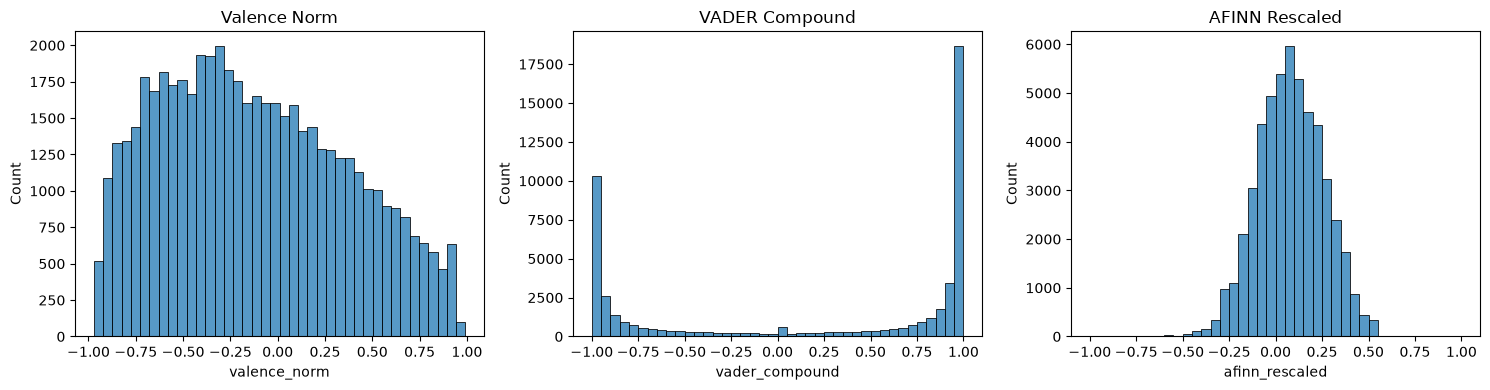

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = 40
cols = ['valence_norm', 'vader_compound', 'afinn_rescaled']
plot_titles = [
    'Valence Norm',
    'VADER Compound',
    'AFINN Rescaled'
]

for i, col in enumerate(cols):
    sns.histplot(sample_songs[col], ax=axes[i], bins=bins)
    axes[i].set_title(plot_titles[i])

plt.tight_layout()
plt.show()

In [28]:
# computing alignment with normalized valence and VADER score
sample_songs['audio_vader_alignment'] = (sample_songs['vader_compound'] - sample_songs['valence_norm']) / 2
sample_songs[['valence_norm', 'vader_compound', 'audio_vader_alignment']].describe()

# computing alignment with normalized valence and AFINN score
sample_songs['audio_afinn_alignment'] = (sample_songs['afinn_rescaled'] - sample_songs['valence_norm']) / 2
sample_songs[['valence_norm', 'afinn_rescaled', 'audio_afinn_alignment']].describe()

,valence_norm,afinn_rescaled,audio_afinn_alignment
count,51891.000000,51891.000000,51891.000000
mean,-0.125290,0.079932,0.102611
std,0.484318,0.177253,0.245825
min,-0.972200,-1.000000,-0.753280
25%,-0.524000,-0.042499,-0.080362
50%,-0.174000,0.073728,0.122390
75%,0.240000,0.205439,0.295324
max,0.992000,1.000000,0.836000


In [29]:
sample_songs.columns

Index(['index', 'id', 'name', 'album_name', 'artists', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers',
       'avg_artist_popularity', 'artist_ids', 'niche_genres',
       'is_valid_lyrics', 'valence_norm', 'vader_compound', 'afinn_raw',
       'afinn_rescaled', 'audio_vader_alignment', 'audio_afinn_alignment'],
      dtype='str')

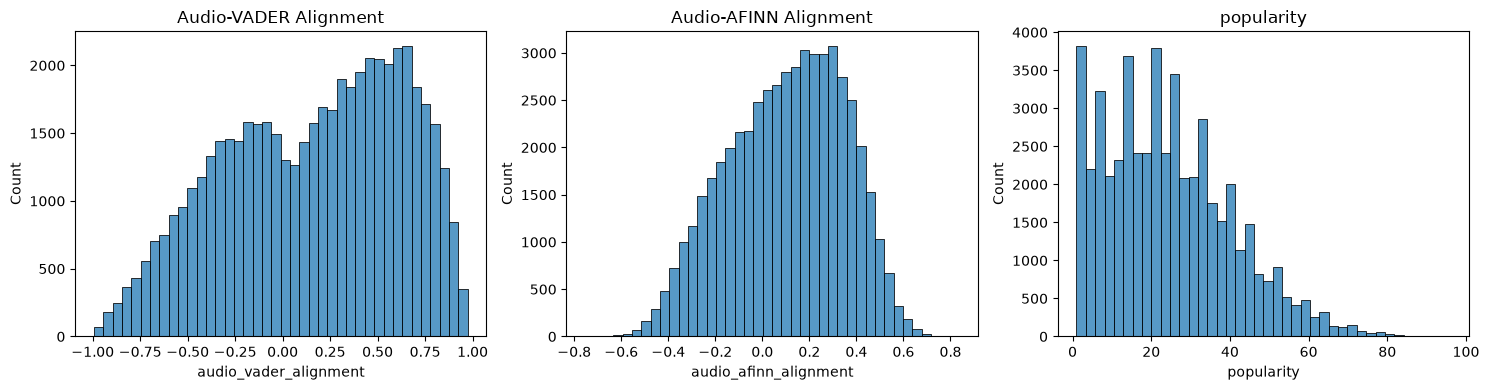

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = 40
cols = ['audio_vader_alignment', 'audio_afinn_alignment', 'popularity']
plot_titles = [
    'Audio-VADER Alignment',
    'Audio-AFINN Alignment',
    'popularity'
]

for i, col in enumerate(cols):
    sns.histplot(sample_songs[col], ax=axes[i], bins=bins)
    axes[i].set_title(plot_titles[i])

plt.tight_layout()
plt.show()